In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from tavily import TavilyClient

tavily_client = TavilyClient()

In [4]:
response = tavily_client.search('What is AI Agent?', max_results=3)
print(response)

{'query': 'What is AI Agent?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://aws.amazon.com/what-is/ai-agents/', 'title': 'What are AI Agents? - Artificial Intelligence - AWS', 'content': '[Skip to main content](https://aws.amazon.com/what-is/ai-agents/#aws-page-content-main) *   [Agentic AI](https://aws.amazon.com/ai/agentic-ai/?nc2=h_l1_f) An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. Multiple AI agents can collaborate to automate complex workflows and can also be used in [agentic ai systems](https://aws.amazon.com/ai/agentic-ai/). For example, a robotic agent collects sensor data, and a[chatbot](https://aws.amazon.com/what-is/chatbot/?refid=faq_card) uses customer queries as input. [Amazon Bedrock Agents](https://aws.amazon.com/bedrock/agents/) use the reasoning of FMs, APIs, and data to break do

In [5]:
response['results']

[{'url': 'https://aws.amazon.com/what-is/ai-agents/',
  'title': 'What are AI Agents? - Artificial Intelligence - AWS',
  'content': '[Skip to main content](https://aws.amazon.com/what-is/ai-agents/#aws-page-content-main) *   [Agentic AI](https://aws.amazon.com/ai/agentic-ai/?nc2=h_l1_f) An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. Multiple AI agents can collaborate to automate complex workflows and can also be used in [agentic ai systems](https://aws.amazon.com/ai/agentic-ai/). For example, a robotic agent collects sensor data, and a[chatbot](https://aws.amazon.com/what-is/chatbot/?refid=faq_card) uses customer queries as input. [Amazon Bedrock Agents](https://aws.amazon.com/bedrock/agents/) use the reasoning of FMs, APIs, and data to break down user requests, gather relevant information, and efficiently complete tasks. [AWS Transform](ht

In [6]:
context = tavily_client.get_search_context(query='What is AI Agent?')

In [7]:
context

'[{"url": "https://aws.amazon.com/what-is/ai-agents/", "content": "[Skip to main content](https://aws.amazon.com/what-is/ai-agents/#aws-page-content-main) *   [Agentic AI](https://aws.amazon.com/ai/agentic-ai/?nc2=h_l1_f) An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. Multiple AI agents can collaborate to automate complex workflows and can also be used in [agentic ai systems](https://aws.amazon.com/ai/agentic-ai/). For example, a robotic agent collects sensor data, and a[chatbot](https://aws.amazon.com/what-is/chatbot/?refid=faq_card) uses customer queries as input. [Amazon Bedrock Agents](https://aws.amazon.com/bedrock/agents/) use the reasoning of FMs, APIs, and data to break down user requests, gather relevant information, and efficiently complete tasks. [AWS Transform](https://aws.amazon.com/transform/) is the first agentic AI service fo

In [8]:
answer = tavily_client.qna_search(query='What is AI Agent?')
print(answer)

An AI agent is a software program that autonomously performs tasks to meet specific goals. It learns from its experiences and can make decisions independently. AI agents automate complex workflows.


In [9]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tool.invoke("What's a 'node' in LangGraph?")

[{'title': 'What is LangGraph? - IBM',
  'url': 'https://www.ibm.com/think/topics/langgraph',
  'content': 'Nodes: In LangGraph, nodes represent individual components or agents within an AI workflow. Nodes can be thought of as “actors” that interact with each other in a specific way. For example,to add nodes for tool calling, one can use the ToolNode. Another example, the next node, refers to the node that will be executed following the current one.',
  'score': 0.92491204},
 {'title': 'LangGraph Glossary',
  'url': 'https://langchain-ai.github.io/langgraphjs/concepts/low_level/',
  'content': 'For more on defining graph state using Zod, see the defining graph state how-to.\n\nNodes¶\n\nIn LangGraph, nodes are typically JavaScript/TypeScript functions (sync or `async`) where the first positional argument is the state, and (optionally), the second positional argument is a "config", containing optional configurable parameters (such as a `thread_id`).\n\nSimilar to `NetworkX`, you add the

In [10]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    '''Adds a and b.
    
    Args:
        a: first int
        b: second int
    '''
    
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    '''Multiplies a and b.
    
    Args:
        a: first int
        b: second int
    '''

    return a * b

tools = [add, multiply]

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
llm_with_tools = llm.bind_tools(tools)


In [12]:
query = "What is 3 * 12? Also, what is 11 + 49?"

llm_with_tools.invoke(query).tool_calls

[{'name': 'multiply',
  'args': {'a': 3, 'b': 12},
  'id': 'call_NzT0q8eg7fP56toHjWpQh4id',
  'type': 'tool_call'},
 {'name': 'add',
  'args': {'a': 11, 'b': 49},
  'id': 'call_VqU9cZLXseZ56obXhKjsxlSK',
  'type': 'tool_call'}]

In [13]:
query = 'What is 12 % 2?'

llm_with_tools.invoke(query).tool_calls

[]

In [14]:
from langchain_openai import ChatOpenAI

tool = TavilySearchResults(max_results=2)
tools = [tool]

llm = ChatOpenAI(model='gpt-4o')
llm_with_tools = llm.bind_tools(tools)

In [15]:
llm_with_tools.invoke('안녕')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 81, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'finish_reason': 'stop', 'logprobs': None}, id='run--a27badfe-a015-4310-be70-77bdb73190d0-0', usage_metadata={'input_tokens': 81, 'output_tokens': 11, 'total_tokens': 92, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [16]:
llm_with_tools.invoke('What is Langgraph?')

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_r5oympsQxb9znX8J9Y5cbApX', 'function': {'arguments': '{"query":"Langgraph"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 84, 'total_tokens': 103, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--747f7181-9ab9-4323-b9e0-04bede75d37b-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Langgraph'}, 'id': 'call_r5oympsQxb9znX8J9Y5cbApX', 'type': 'tool_call'}], usage_metadata={'input_tokens': 84, 'output_tokens': 19, 'total_tokens': 103, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

In [17]:
llm_with_tools.invoke('What is Langgraph?').tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Langgraph'},
  'id': 'call_U1J3dA2Kn5inYBdtoVhhiY2i',
  'type': 'tool_call'}]

In [26]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

def chatbot(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

graph_builder.add_node('chatbot', chatbot)

In [27]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    '''
        A node that runs the tools requested in the last AIMessage.
        마지막 AIMessage에서 요청된 도구를 실행하는 노드
    '''

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get('messages', []):
            message = messages[-1]
        else:
            raise ValueError('No message found in input')
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args'])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call['name'],
                    tool_call_id=tool_call['id']
                )
            )
        return {'messages': outputs}

tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node('tools', tool_node)

In [28]:
def route_tools(
    state: State,
):
    '''
    Use in the conditional_edge to route to the ToolNode if the last message has tool calls. Otherwise, route to the end.
    '''
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get('messages', []):
        ai_message = messages[-1]
    else:
        raise ValueError(f'No Messages found in input state to tool_edge: {state}')
    if hasattr(ai_message, 'tool_calls') and len(ai_message.tool_calls) > 0:
        return 'tools'
    return END

graph_builder.add_conditional_edges(
    'chatbot',
    route_tools,
    {'tools': 'tools', END: END}
)

In [29]:
graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START, 'chatbot')
graph = graph_builder.compile()

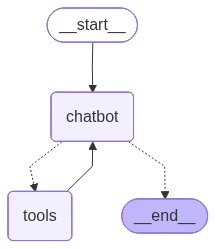

In [30]:
from IPython.display import Image, display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [31]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({'messages': [{'role': 'user', 'content': user_input}]}):
        for value in event.values():
            print('Assistant: ', value['messages'][-1].content)

In [32]:
while True:
    try:
        user_input = input('User: ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break

        stream_graph_updates(user_input)
    except:
        user_input = 'What do you know about LangGraph?'
        print('User: ' + user_input)
        stream_graph_updates(user_input)
        break

Assistant:  안녕하세요! 무엇을 도와드릴까요?
Goodbye!


In [33]:
while True:
    try:
        user_input = input('User: ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break
        print('User: '+user_input)
        stream_graph_updates(user_input)
    except:
        user_input = 'What do you know about LangGraph?'
        print('User: ' + user_input)
        stream_graph_updates(user_input)
        break

User: 안녕?
Assistant:  안녕하세요! 어떻게 도와드릴까요?
User: 랭그래프가 뭐야?
Assistant:  
Assistant:  [{"title": "LangGraph - 1. \uac1c\uc694 - \uccad\ucd98\ub9cc\ud654 - \ud2f0\uc2a4\ud1a0\ub9ac", "url": "https://normalstory.tistory.com/entry/LangGraph-01", "content": "LangGraph\ub294 Agent \ub7f0\ud0c0\uc784\uc5d0 \uc790\uc8fc \ud544\uc694\ud55c '\uc8fc\uae30\uc801 \uadf8\ub798\ud504workflows containingcycles'\ub97c \ub354 \uc798 \uc0dd\uc131\ud560 \uc218 \uc788\ub3c4\ub85d LangChain \uc704\uc5d0 \uad6c\ucd95\ub41c \ubaa8\ub4c8\uc774\ub2e4. \ub530\ub77c\uc11c \uc8fc\uc694 \uc6a9\ub3c4\ub294 \uc55e\uc11c \uc5b8\uae09\ud588\ub4ef\uc774 'LLM \uc560\ud50c\ub9ac\ucf00\uc774\uc158'\uc5d0 Agent\ub97c \ud638\ucd9c\ud558\ub294 '\uc8fc\uae30 Cycles'\uc744 \ucd94\uac00\ud558\uc5ec \ub2e4\uc74c \uc218\ud589\ud560 \uc791\uc5c5\uc744 \uc9c0\uc815\ud558\ub294 \uac83\uc774\ub2e4. \uc774\ub97c\ud14c\uba74 \uc5b4\ub5a4 \uc0c1\ud0dc\uc77c\ub54c \ud2b9\uc815 '\uccb4\uc778'\uc744 \uc2e4\ud589\ud558\uac70\ub098 \ud2b9\uc815 